In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

In [3]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [8]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    

In [ ]:
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages":[response]}


In [10]:
graph = StateGraph(ChatState)
graph.add_node("Chat Node", chat_node)
graph.add_edge(START,'Chat Node')
graph.add_edge('Chat Node',END)
chatbot = graph.compile()

In [12]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

In [11]:
graph = StateGraph(ChatState)
graph.add_node("Chat Node", chat_node)
graph.add_edge(START,'Chat Node')
graph.add_edge('Chat Node',END)
chatbot = graph.compile()

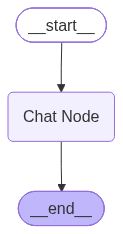

In [13]:
chatbot

In [16]:
initial_state = {
    "messages" : [HumanMessage(content = 'give me best 2020-2026 telugu songs?')]
}
response = chatbot.invoke(initial_state)
response

{'messages': [HumanMessage(content='give me best 2020-2026 telugu songs?', additional_kwargs={}, response_metadata={}, id='952c788a-0479-402b-b03f-9d3816d18da2'),
  AIMessage(content='Here’s a curated list of Telugu songs that have been especially popular (or critically acclaimed) from\u202f2020\u202fthrough\u202f2024\u202f—\u202fthe most recent years for which reliable information is available. I’ve grouped them by year, noted the movie (or album) they belong to, the primary singers/composers, and a quick note on why each track stood out.  \n\n---\n\n## 2020  \n\n| # | Song | Film / Album | Singer(s) | Composer | Why it’s memorable |\n|---|------|--------------|-----------|----------|--------------------|\n| 1 | **“Butta Bomma”** | *Ala\u202fVaikunthapurramuloo* | Armaan Malik | Thaman S | Catchy hook, viral dance challenge, massive YouTube views (>\u202f400\u202fM). |\n| 2 | **“Samajavaragamana”** | *Ala\u202fVaikunthapurramuloo* | Sid Sriram | Thaman S | Classical‑infused melody, ly

In [21]:
while True:
    user_message = input("Type here:")
    print("User:",user_message)
    if user_message.strip().lower() in ['exist','quit','bye']:
       print("AI: Thankyou for the visiting!")
    break
response = chatbot.invoke({'messages': [HumanMessage(content = user_message)]})
print("AI:",response['messages'][-1].content)


User: what is my name
AI: I’m not able to see your name. If you’d like, you can tell me what you’d like to be called!


In [22]:
from langgraph.checkpoint.memory import MemorySaver

In [23]:
checkpoint = MemorySaver()
graph = StateGraph(ChatState)
graph.add_node("Chat Node", chat_node)
graph.add_edge(START,'Chat Node')
graph.add_edge('Chat Node',END)
chatbot = graph.compile()
chatbot = graph.compile(checkpointer = checkpoint)

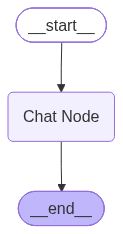

In [24]:
chatbot

In [ ]:
thread_id = "1"
while True:
    user_message = input("Type here:")
    print("User:",user_message)
    if user_message.strip().lower() in ['exist','quit','bye']:
       print("AI: Thankyou for the visiting!")
    break
config = {"configurable" : {"thread_id" : thread_id}}
response = chatbot.invoke({'messages': [HumanMessage(content = user_message)]},config = config)
print("AI:",response['messages'][-1].content)


User: what is my name?
AI: Your name is Naveen.
